# Week 4 Lab: Explore regularisation and cross-validation with MNIST
[PRML 2026 Dr Min Wang]

## Objective
In week 3 lab, you have leant:
- how to load and explore the MNIST dataset.
- how to preprocess images for logistic regression.
- how to train and evaluate a logistic regression classifier.
- and how to interpret the results and identify strengths/weaknesses.

This week lab, you will learn:
- how to use regulatisation to prevent overfitting
- how to apply k-fold cross validation to evaluate the model performance


## Introduction to MNIST Digit Classification

The MNIST dataset is a widely used benchmark in machine learning and computer vision. It consists of 70,000 grayscale images of handwritten digits (0 through 9), each sized 28×28 pixels. The goal of MNIST digit classification is to develop models that can accurately recognize and classify these images into their correct digit categories.

Because of its simplicity and well-structured format, MNIST serves as an excellent starting point for learning image classification techniques, including logistic regression, neural networks, and deep learning models. Success on MNIST demonstrates a model’s ability to extract meaningful features from image data and make accurate predictions on unseen samples.

In this lab, we will use the logistic regression model for classification. Logistic regression is a simple yet powerful statistical method that predicts the probability of an input belonging to a particular class. For MNIST, it models the probability that an image corresponds to each digit from 0 to 9. Despite its simplicity compared to deep learning models, logistic regression can achieve surprisingly good accuracy on MNIST and serves as a great introduction to classification algorithms.


## Prerequisites
You’ll need:
Python 3.x installed
scikit-learn, numpy, matplotlib, and tensorflow installed

## Step-by-Step Instructions

### Step 1: Import libraries
We import essential libraries for this task:
1. NumPy for numerical operations.
2. Matplotlib for data visualization.
3. scikit-learn for building and evaluating the logistic regression model. LogisticRegression from scikit-learn will be our classifier. We will use KFold and cross_val_score from scikit-learn for k-fold cross validation.
4. classification_report & confusion_matrix help evaluate performance.
5. TensorFlow to load the MNIST dataset easily. We use MNIST directly from Keras for convenience.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist


### Step 2: Load the MNIST dataset
In this step, we load the MNIST handwritten digit dataset using TensorFlow’s built-in tf.keras.datasets.mnist.load_data() function. This provides the dataset split into training and testing sets directly as NumPy arrays. Each image is a 28x28 grayscale pixel array, and the labels are integers from 0 to 9. This built-in method is convenient and efficient for quick access to the dataset.
1. MNIST contains 28×28 grayscale digit images (0–9).
2. x_train has 60,000 images, x_test has 10,000.

In [2]:
# Load data: (x_train, y_train) for training, (x_test, y_test) for testing
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Put train and test together into a whole dataset (we do this because we want to use k-fold cross validation)
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

print("Dataset shape:", X.shape)


Dataset shape: (70000, 28, 28)


### Step 3: Visualize sample images
Here we display nine images from the training set. This visualization helps familiarize you with the dataset and confirms that the images and labels align.

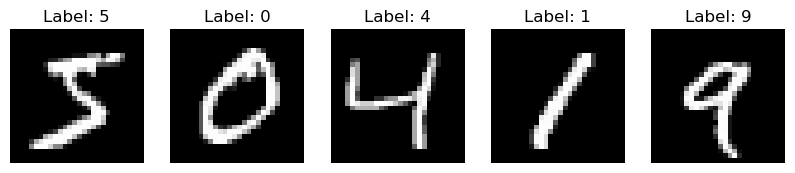

In [3]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()


### Step 4: Preprocess the data
Since logistic regression expects input as feature vectors, each 28x28 image will need to be flattened into a one-dimensional 784-length vector. We also normalize pixel values from 0–255 to 0–1 to improve model performance and training stability.
1. Flattening: Logistic regression expects 1D feature vectors.
2. Normalization: Helps model convergence and stability.

In [4]:
# Flatten images (28*28 -> 784)
X = X.reshape(-1, 28*28)

# Normalize pixel values (0-255 -> 0-1)
X = X / 255.0

### Step 5: Define 5-fold cross-validation

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Step 6: Create the logistic regression models
Here, we will create four models:
1) model_v0 is a logistic regression model without any regularisation
2) model_l1 is a logistic regression model with L1 regularisation
3) model_l2 is a logistic regression model with L2 regularisation
4) model_l1l2 is a logistic regression model with both L1 and L2 regularisation

Details about the parameters of LogisticRegression are available via the link:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [6]:
model_v0 = LogisticRegression(
    penalty=None,     # No penalty is added
    solver='lbfgs',   # Solver that supports no regularization
    max_iter=500,     # Number of iterations
    random_state=42
)

model_l1 = LogisticRegression(
    penalty="l1",              # L1 regularization only
    solver="liblinear",        # 'liblinear' or 'saga' works for L1
    C=1.0,                     # Inverse of regularization strength
    max_iter=500,              # Ensure convergence
    random_state=42
)

model_l2 = LogisticRegression(
    penalty="l2",              # L2 regularization only
    solver="lbfgs",            # Default solver works well with L2
    C=1.0,                     # Inverse of regularization strength
    max_iter=500,              # Ensure convergence
    random_state=42
)

model_l1l2 = LogisticRegression(
    penalty="elasticnet",      # Use both L1 and L2
    solver="saga",             # Required for elasticnet
    l1_ratio=0.5,              # Balance between L1 and L2 (0 = L2 only, 1 = L1 only)
    C=1.0,                     # Inverse of regularization strength
    max_iter=500,              # Ensure convergence
    random_state=42
)


### Step 7: Evaluate with Cross-Validation
Instead of training and testing once, we use k-fold cross-validation (CV).
- The dataset is split into k parts (here, 5).
- The model trains on 4 parts and tests on the remaining 1 part.
- This repeats k times, so every sample is used for testing exactly once.

Cross-validation gives a more reliable estimate of model performance than a single train-test split. It reduces the risk that your results depend on how the data was split. You get a distribution of accuracy scores instead of just one number.

In [ ]:
print("Evaluating base model...")
scores_v0 = cross_val_score(model_v0, X, y, cv=kf, scoring="accuracy", n_jobs=-1)

print("Evaluating L1 model...")
scores_l1 = cross_val_score(model_l1, X, y, cv=kf, scoring="accuracy", n_jobs=-1)

print("Evaluating L2 model...")
scores_l2 = cross_val_score(model_l2, X, y, cv=kf, scoring="accuracy", n_jobs=-1)

print("Evaluating L1 and L2 model...")
scores_l1l2 = cross_val_score(model_l1l2, X, y, cv=kf, scoring="accuracy", n_jobs=-1)

# 6. Results
print("\nResults (5-fold cross-validation on MNIST subset):")
print(f"V0 Accuracy: {scores_v0.mean():.4f} ± {scores_v0.std():.4f}")
print(f"L1 Accuracy: {scores_l1.mean():.4f} ± {scores_l1.std():.4f}")
print(f"L2 Accuracy: {scores_l2.mean():.4f} ± {scores_l2.std():.4f}")
print(f"L1+L2 Accuracy: {scores_l1l2.mean():.4f} ± {scores_l1l2.std():.4f}")
